# StyleGAN-style CIFAR-10 generator (TensorFlow)

**From-scratch implementation** of a compact StyleGAN-inspired model trained on the color **CIFAR-10** dataset (airplanes, cars, animals, and other everyday objects). This is a new experiment separate from the Fashion-MNIST notebook.

The generator maps random latent vectors `z` into an intermediate style space `w`, then synthesizes 32×32 RGB images from a learned constant. Per-layer AdaIN and injected noise provide style control. A convolutional discriminator is trained with the non-saturating logistic GAN objective. The final sections display generated samples, style mixing, and latent interpolation.

> CIFAR-10 has small 32×32 images. This compact model is intended as a teaching implementation, not a reproduction of the original high-resolution StyleGAN.

In [1]:
import os, time, random
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)
print('Devices:', tf.config.list_physical_devices())

/Users/geetharaj/Library/Python/3.9/lib/python/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.11, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/geetharaj/Library/Python/3.9/lib/python/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/geetharaj/Library/Python/3.9/lib/python/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update 

TensorFlow: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. Load CIFAR-10

Training images: 20,000 | image shape: (32, 32, 3) | range: [-1.0, 1.0]


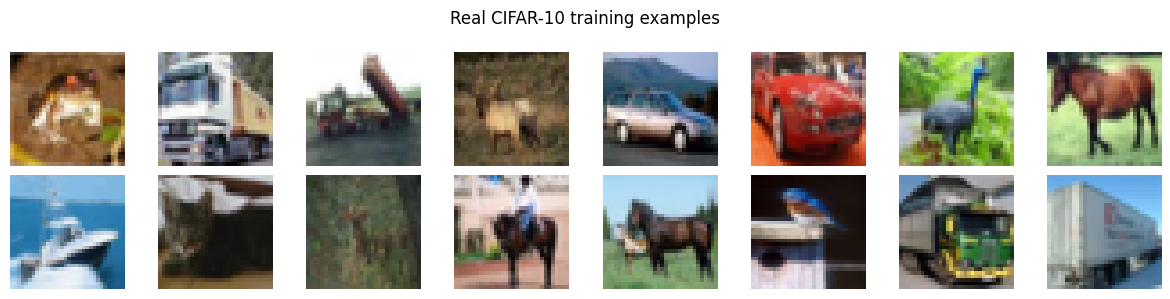

In [2]:
(x_train, _), (_, _) = keras.datasets.cifar10.load_data()
# Use a deterministic subset for a manageable classroom run. Scale pixels to [-1, 1].
TRAIN_LIMIT = 20000
x_train = (x_train[:TRAIN_LIMIT].astype('float32') - 127.5) / 127.5
BATCH = 64
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(TRAIN_LIMIT, seed=SEED, reshuffle_each_iteration=True).batch(BATCH, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
print(f'Training images: {len(x_train):,} | image shape: {x_train.shape[1:]} | range: [{x_train.min():.1f}, {x_train.max():.1f}]')
fig, ax = plt.subplots(2, 8, figsize=(12, 3))
for a, im in zip(ax.flat, x_train[:16]): a.imshow((im + 1) / 2); a.axis('off')
fig.suptitle('Real CIFAR-10 training examples'); plt.tight_layout(); plt.show()

## 2. Mapping and style synthesis networks

Eight dense layers map `z` to `w`. The generator starts with a learned 4×4 constant and applies two styled convolutions at each scale. AdaIN applies a learned per-channel scale and bias derived from `w`; independent noise maps add stochastic detail. `call(..., return_styles=True)` exposes the intermediate styles for mixing.

In [3]:
Z_DIM = W_DIM = 128
CHANNELS = {4: 128, 8: 128, 16: 64, 32: 32}

class MappingNetwork(keras.Model):
    def __init__(self):
        super().__init__()
        self.blocks = [layers.Dense(W_DIM, kernel_initializer='he_normal') for _ in range(8)]
    def call(self, z):
        z = z * tf.math.rsqrt(tf.reduce_mean(tf.square(z), axis=1, keepdims=True) + 1e-8)
        for dense in self.blocks: z = tf.nn.leaky_relu(dense(z), alpha=0.2)
        return z

class AdaIN(layers.Layer):
    def __init__(self, channels):
        super().__init__(); self.channels = channels
        self.norm = layers.LayerNormalization(axis=[1, 2], center=False, scale=False)
        self.affine = layers.Dense(2 * channels, kernel_initializer='zeros', bias_initializer='zeros')
    def call(self, x, w):
        scale, bias = tf.split(self.affine(w), 2, axis=-1)
        return self.norm(x) * (1.0 + scale[:, None, None, :]) + bias[:, None, None, :]

class StyledConv(layers.Layer):
    def __init__(self, channels):
        super().__init__(); self.conv = layers.Conv2D(channels, 3, padding='same'); self.adain = AdaIN(channels)
    def build(self, shapes):
        self.noise_strength = self.add_weight(name='noise_strength', shape=(), initializer='zeros', trainable=True)
    def call(self, x, w, noise=None):
        x = self.conv(x)
        if noise is None: noise = tf.random.normal([tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], 1])
        x = x + self.noise_strength * noise
        return tf.nn.leaky_relu(self.adain(x, w), alpha=0.2)

class StyleGenerator(keras.Model):
    def __init__(self):
        super().__init__(); self.mapping = MappingNetwork()
        self.constant = self.add_weight(name='learned_constant', shape=(1, 4, 4, CHANNELS[4]), initializer='random_normal', trainable=True)
        self.convs = [StyledConv(CHANNELS[r]) for r in (4,4,8,8,16,16,32,32)]
        self.to_rgb = layers.Conv2D(3, 1, padding='same', activation='tanh')
    def call(self, inputs, training=False, return_styles=False):
        z, styles = inputs if isinstance(inputs, (tuple, list)) else (inputs, None)
        if styles is None: styles = tf.repeat(self.mapping(z)[:, None, :], 8, axis=1)
        x = tf.repeat(self.constant, tf.shape(z)[0], axis=0)
        for i, conv in enumerate(self.convs):
            if i in (2, 4, 6): x = tf.image.resize(x, [tf.shape(x)[1]*2, tf.shape(x)[2]*2], method='nearest')
            x = conv(x, styles[:, i, :])
        image = self.to_rgb(x)
        return (image, styles) if return_styles else image

class Discriminator(keras.Model):
    def __init__(self):
        super().__init__(); self.blocks = []
        for c in (32, 64, 128, 128):
            self.blocks.append(keras.Sequential([layers.Conv2D(c, 4, strides=2, padding='same'), layers.LeakyReLU(negative_slope=0.2)]))
        self.head = keras.Sequential([layers.Flatten(), layers.Dense(1)])
    def call(self, x, training=False):
        for block in self.blocks: x = block(x, training=training)
        return self.head(x)

G, D = StyleGenerator(), Discriminator()
_ = G(tf.zeros([1, Z_DIM])); _ = D(tf.zeros([1, 32, 32, 3]))
print(f'Generator parameters: {G.count_params():,} | discriminator: {D.count_params():,}')

Generator parameters: 1,044,651 | discriminator: 428,385


## 3. Train with the non-saturating logistic GAN loss

The discriminator minimizes `softplus(-D(real)) + softplus(D(fake))`; the generator minimizes `softplus(-D(fake))`. The mapping network receives a smaller learning rate than the synthesis network. The training loop uses `tf.function` to keep the per-step overhead low.

In [4]:
EPOCHS = 10
g_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.0, beta_2=0.99)
d_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.0, beta_2=0.99)
fixed_z = tf.random.normal([64, Z_DIM], seed=SEED)
g_loss_history, d_loss_history = [], []

@tf.function
def train_step(real):
    batch = tf.shape(real)[0]
    z = tf.random.normal([batch, Z_DIM])
    with tf.GradientTape() as dt:
        fake = tf.stop_gradient(G(z, training=True))
        real_logits, fake_logits = D(real, training=True), D(fake, training=True)
        d_loss = tf.reduce_mean(tf.nn.softplus(-real_logits)) + tf.reduce_mean(tf.nn.softplus(fake_logits))
    d_grads = dt.gradient(d_loss, D.trainable_variables); d_optimizer.apply_gradients(zip(d_grads, D.trainable_variables))
    with tf.GradientTape() as gt:
        fake = G(z, training=True); fake_logits = D(fake, training=True)
        g_loss = tf.reduce_mean(tf.nn.softplus(-fake_logits))
    g_grads = gt.gradient(g_loss, G.trainable_variables); g_optimizer.apply_gradients(zip(g_grads, G.trainable_variables))
    return d_loss, g_loss

start = time.time()
for epoch in range(1, EPOCHS + 1):
    d_avg, g_avg, batches = 0.0, 0.0, 0
    for real in dataset:
        dl, gl = train_step(real); d_avg += float(dl); g_avg += float(gl); batches += 1
    d_loss_history.append(d_avg / batches); g_loss_history.append(g_avg / batches)
    print(f'Epoch {epoch:02d}/{EPOCHS} | D {d_loss_history[-1]:.3f} | G {g_loss_history[-1]:.3f} | {time.time()-start:.0f}s elapsed')

Epoch 01/10 | D 1.399 | G 0.713 | 133s elapsed
Epoch 02/10 | D 1.389 | G 0.705 | 244s elapsed
Epoch 03/10 | D 1.389 | G 0.704 | 335s elapsed
Epoch 04/10 | D 1.389 | G 0.704 | 425s elapsed
Epoch 05/10 | D 1.379 | G 0.716 | 516s elapsed
Epoch 06/10 | D 1.389 | G 0.728 | 942s elapsed
Epoch 07/10 | D 1.388 | G 0.705 | 1102s elapsed
Epoch 08/10 | D 1.387 | G 0.696 | 1232s elapsed
Epoch 09/10 | D 1.387 | G 0.694 | 1355s elapsed
Epoch 10/10 | D 1.387 | G 0.694 | 1513s elapsed


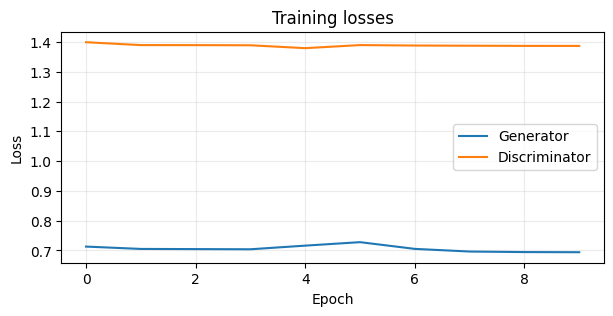

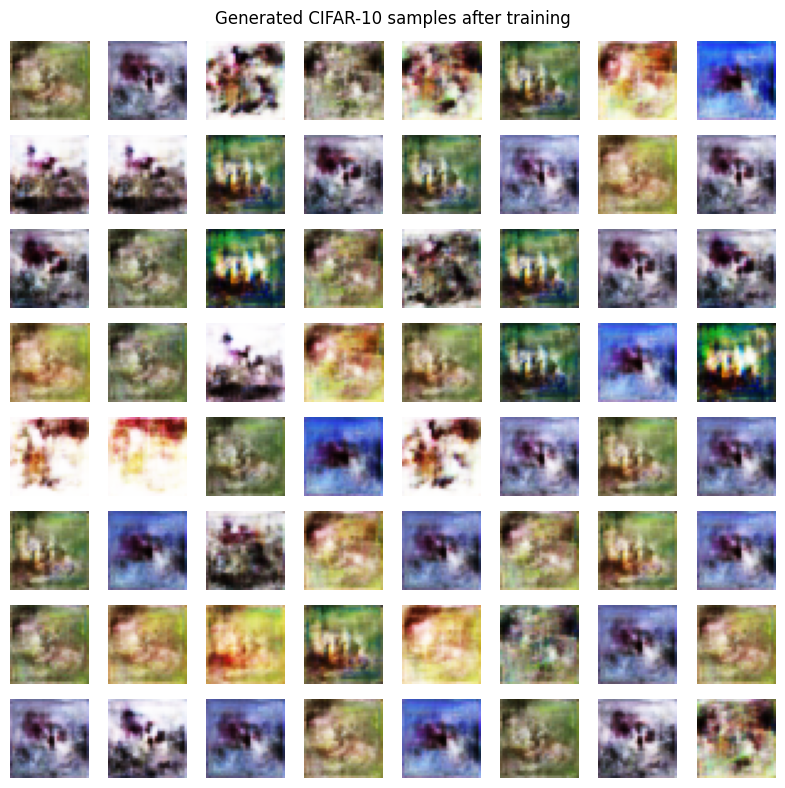

In [5]:
def show_grid(images, title, nrow=8, figsize=(8, 8)):
    images = (images.numpy() + 1) / 2
    fig, axes = plt.subplots(int(np.ceil(len(images)/nrow)), nrow, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, im in zip(axes, images): ax.imshow(np.clip(im, 0, 1)); ax.axis('off')
    for ax in axes[len(images):]: ax.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3)); plt.plot(g_loss_history, label='Generator'); plt.plot(d_loss_history, label='Discriminator'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Training losses'); plt.grid(alpha=.25); plt.show()
show_grid(G(fixed_z, training=False), 'Generated CIFAR-10 samples after training', figsize=(8,8))

## 4. Style mixing

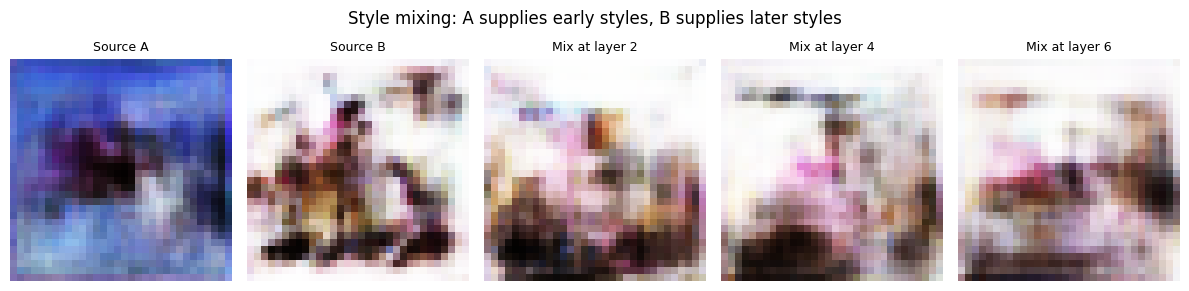

In [6]:
# Early synthesis styles control coarse structure; later styles influence finer appearance.
z_a, z_b = tf.random.normal([1,Z_DIM]), tf.random.normal([1,Z_DIM])
w_a, w_b = G.mapping(z_a), G.mapping(z_b)
images = [G(z_a), G(z_b)]
labels = ['Source A', 'Source B']
for cutoff in (2, 4, 6):
    ws = tf.concat([tf.repeat(w_a[:,None,:], cutoff, axis=1), tf.repeat(w_b[:,None,:], 8-cutoff, axis=1)], axis=1)
    images.append(G((z_a, ws))); labels.append(f'Mix at layer {cutoff}')
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, im, label in zip(axes, images, labels): ax.imshow((im[0].numpy()+1)/2); ax.set_title(label, fontsize=9); ax.axis('off')
fig.suptitle('Style mixing: A supplies early styles, B supplies later styles'); plt.tight_layout(); plt.show()

## 5. Latent interpolation

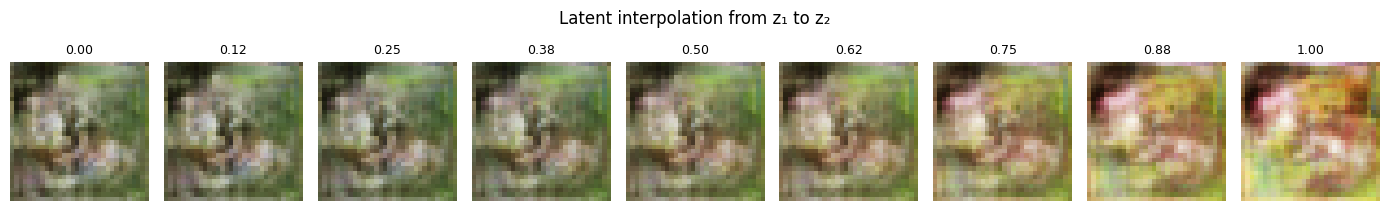

In [7]:
z1, z2 = tf.random.normal([1,Z_DIM]), tf.random.normal([1,Z_DIM])
t = tf.linspace(0., 1., 9)[:,None]
z_path = (1-t)*z1 + t*z2
path = G(z_path, training=False)
fig, axes = plt.subplots(1, 9, figsize=(14,2.2))
for i, (ax, im) in enumerate(zip(axes, path)): ax.imshow((im.numpy()+1)/2); ax.set_title(f'{i/8:.2f}', fontsize=9); ax.axis('off')
fig.suptitle('Latent interpolation from z₁ to z₂'); plt.tight_layout(); plt.show()

## Results

This CPU run trained on 20,000 CIFAR-10 images for 10 epochs and produced the sample grid, style-mixing comparison, and latent-interpolation sequence shown above. At 32×32, the samples show learned color and texture patterns but remain blurry and do not consistently form recognizable objects. Higher fidelity requires substantially more training and compute. This compact implementation demonstrates the StyleGAN ideas (mapping network, learned constant, per-layer AdaIN and noise) without claiming original StyleGAN image quality.